## Exploration for the dashboard

In [94]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

#### Data summary

In [ ]:
df = pd.read_csv("marketing_campaign_dataset.csv")
df 

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,TechCorp,Display,All Ages,30 days,Google Ads,0.06,"$18,365.00",2.84,Chicago,German,858,5988,1,Tech Enthusiasts,2021-12-07
199996,199997,DataTech Solutions,Email,Men 25-34,15 days,Facebook,0.02,"$8,168.00",4.14,Chicago,Spanish,228,3068,7,Foodies,2021-12-08
199997,199998,DataTech Solutions,Social Media,Men 18-24,45 days,Website,0.05,"$13,397.00",3.25,New York,Mandarin,723,9548,3,Tech Enthusiasts,2021-12-09
199998,199999,Innovate Industries,Influencer,All Ages,30 days,YouTube,0.10,"$18,508.00",3.86,Houston,French,528,2763,1,Foodies,2021-12-10


In [4]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [8]:
def check_data(dataframe, head=5):
    print(" SHAPE ".center(70,'-'))
    print('Rows: {}'.format(dataframe.shape[0]))
    print('Columns: {}'.format(dataframe.shape[1]))
    print(" TYPES ".center(70,'-'))
    print(dataframe.dtypes)
    print(" HEAD ".center(70,'-'))
    print(dataframe.head(head))
    print(" TAIL ".center(70,'-'))
    print(dataframe.tail(head))
    print(" MISSING VALUES ".center(70,'-'))
    print(dataframe.isnull().sum())
    print(" DUPLICATED VALUES ".center(70,'-'))
    print(dataframe.duplicated().sum())
    #print(" QUANTILES ".center(70,'-'))
    #print(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)
check_data(df)

------------------------------- SHAPE --------------------------------
Rows: 200000
Columns: 16
------------------------------- TYPES --------------------------------
Campaign_ID           int64
Company              object
Campaign_Type        object
Target_Audience      object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost     object
ROI                 float64
Location             object
Language             object
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment     object
Date                 object
dtype: object
-------------------------------- HEAD --------------------------------
   Campaign_ID              Company Campaign_Type Target_Audience Duration  \
0            1  Innovate Industries         Email       Men 18-24  30 days   
1            2       NexGen Systems         Email     Women 35-44  60 days   
2            3    Alpha Innovations    Influencer       Men 25-34 

In [34]:
df['Language'].describe()

count       200000
unique           5
top       Mandarin
freq         40255
Name: Language, dtype: object

In [35]:
# Creating an empty dictionary
my_dict = {}

# Adding multiple key-value pairs using comprehension
my_dict.update({f'key{i}': f'value{i}' for i in range(1, 4)})

# Display the updated dictionary
print(my_dict)

{'key1': 'value1', 'key2': 'value2', 'key3': 'value3'}


[Text(0, 0, '1.85007e+08'),
 Text(0, 0, '1.83448e+08'),
 Text(0, 0, '1.83738e+08'),
 Text(0, 0, '1.83806e+08'),
 Text(0, 0, '1.80659e+08'),
 Text(0, 0, '1.84801e+08')]

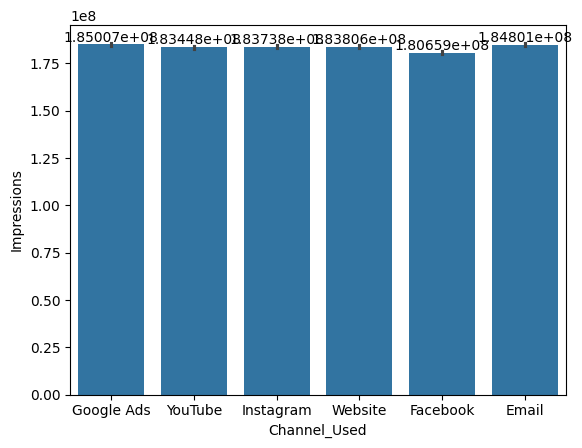

In [112]:
df[df['Channel_Used']=='Google Ads']
grouped = df.groupby('Channel_Used')['Conversion_Rate'].mean()
sql = grouped.to_frame()
chn = df['Channel_Used']
clicks = df['Clicks']


#sns.pairplot(df, 
#            x_vars=['Conversion_Rate', 'ROI', 'Clicks','Impressions','Engagement_Score'],
#             y_vars=['Conversion_Rate', 'ROI', 'Clicks','Impressions','Engagement_Score'])

ax = sns.barplot(df, x='Channel_Used',y="Impressions", estimator="sum")
ax.bar_label(ax.containers[0], fontsize = 10)


<Axes: xlabel='body_mass_g', ylabel='Count'>

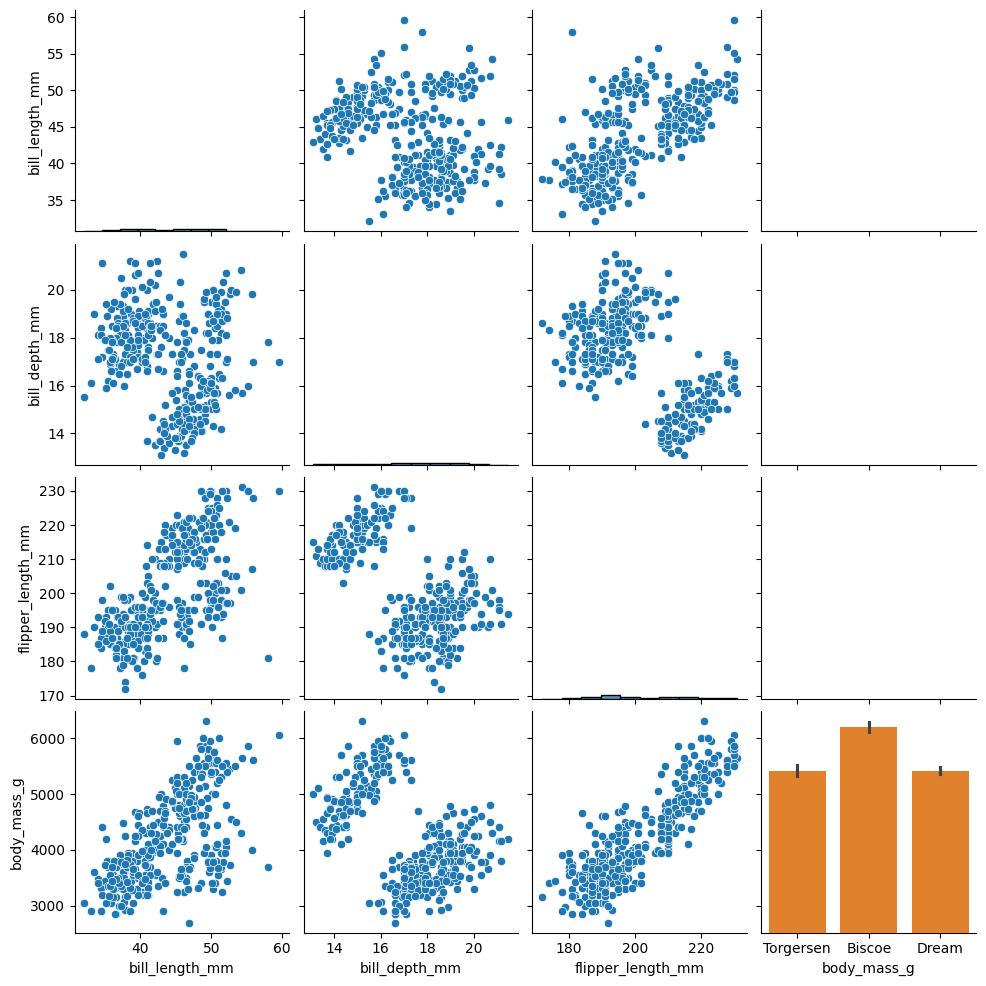

In [102]:
penguins = sns.load_dataset('penguins')
sns.pairplot(penguins)
sns.barplot(penguins, x="island", y="body_mass_g")